# *Music Genre Classification - Classifying the genre of a music using deep neural networks*

## Introduction
Music Genre classification is one of the branches of *Music Information Retrieval
(MIR)*. A robust recommendation system begins with the categorization of music
genres. Sound processing is a huge reaseach area through which we can find solutions to various medical or mental issues through music theraphy solutions. There are various music applications such as Spotify, Google Play, Apple
Music, etc., but for implementation, one of the most important steps is to classify the
genre of a music which requires audio processing, it is one of the most complex tasks
that involves time  signal processing, time series, spectrograms, spectral coefficients, and audio feature
extraction to feed a neural network.

## Dataset description
The dataset used is [GTZAN](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification) (the famous GTZAN dataset, the MNIST of sounds)

The GTZAN dataset contains 1000 audio files.
Contains a total of 10 genres, each genre contains 100 audio files

1.Blues

2.Classical

3.Country

4.Disco   

5.Hip-hop

6.Jazz   

7.Metal

8.Pop

9.Reggae

10.Rock

##### Genres original  
A compilation of ten genres, each with 100 audio recordings, each lasting 30 seconds (the famous GTZAN dataset, the MNIST of sounds)
##### Images original
Each audio file has a visual representation. Neural networks are one technique to classify data because they usually take in some form of picture representation.
##### CSV files
The audio files' features are contained within. Each song lasts for 30 seconds long has a mean and variance computed across several features taken from an audio file in one file. The songs are separated into 3 second audio files in the other file, which has the same format.


## Tensorflow
TensorFlow is a python's open source library developed by google which provides a collection of workflows to develop and train models using Python or JavaScript, and to easily deploy in the cloud, on-prem, in the browser, or on-device no matter what language you use. The tf. data API enables you to build complex input pipelines from simple, reusable pieces.
It is used ease the process of acquiring data, training models, serving predictions, and refining future results.

Tensorflow makes it easy to work on our machine learning and deep learning models, hence We used tensorflow and keras in our notebook to train and test the deep learning model.


## Import libraries

In [2]:
# Importing all the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import pickle
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential

In [3]:
# Reading the csv file
df = pd.read_csv("features_3_sec.csv")
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [4]:
# Shape of the data
df.shape

(9990, 60)

In [5]:
# Data type of the data
df.dtypes

,0
filename,object
length,int64
chroma_stft_mean,float64
chroma_stft_var,float64
rms_mean,float64
rms_var,float64
spectral_centroid_mean,float64
spectral_centroid_var,float64
spectral_bandwidth_mean,float64
spectral_bandwidth_var,float64


## Proposed Methodology
   ![Untitled Diagram.drawio (2).png](attachment:40f55db0-d807-4358-b63e-4f3c23c3898f.png)

In order to work with audio data we use [Librosa](https://librosa.org/doc/latest/index.html), a python
package used for audio and music analysis. It is a powerful package widely used for
audio visualization and for building MIR systems. We will be using the package for
loading and visualizing the audio data.

It is important to note that while working with any kind of audio data to solve any kind of problem statement, using only .wav format audio files is appropriate to analyze the data. If you are given audio files with .mp3 format you have to batch convert the data to waveforms using online software as .wav is the standard way of representing the audio files and it is the only way to work with audio data. Below is the wave form representation on the audio

A spectrogram is a visual representation of the signal loudness of a signal over time at different frequencies included in a certain waveform. We can examine increase or decrease of energy over period of time. Spectrograms are also known as sonographs, voiceprints, and voicegrams.  We can also know how energy levels change over time period.

## Data Pre Processing

### Extracting Audio features
The process of extraction of features from the data to utilize them for analysis is
known as feature extraction. Each audio signal consists of various audio features
however we must extract features that are relevant to the problem that we are solving.
Here are some features listed which are used in our project.

### Spectral roll off
It computes the rolloff frequency for each frame in a given signal. The frequency under which some percentage (cutoff) of the total energy of a spectrum is obtained. It can be used to differentiate between the harmonic and noisy sounds.   Spectral Roll off

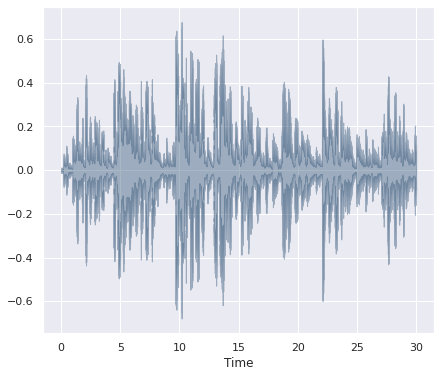

In [ ]:
spectral_rolloff=librosa.feature.spectral_rolloff(y=data,sr=sr)[0]
plt.figure(figsize=(7,6))
librosa.display.waveshow(data,sr=sr,alpha=0.4,color="#2B4F72")

### Chroma feature
It closely relates with the twelve different pitch classes. Chroma based features are also called as pitch class profiles. It is the powerful tool for analyzing and categorizing them. Harmonic and melodic characteristics of music are captured by them. Chroma featue

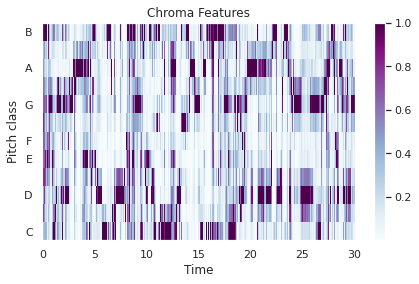

In [ ]:
import librosa.display as lplt
chroma = librosa.feature.chroma_stft(y=data,sr=sr)
plt.figure(figsize=(7,4))
lplt.specshow(chroma,sr=sr,x_axis="time",y_axis="chroma",cmap="BuPu")
plt.colorbar()
plt.title("Chroma Features")
plt.show()

### Zero Crossing Rate
It is the rate at which a signal transitions from positive to zero to negative or from negative to zero or simply said the number of times the signal crosses x-axis is as the zero-crossing rate (ZCR).

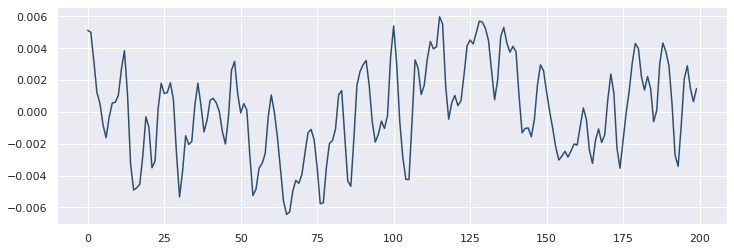

In [ ]:
start=1000
end=1200
plt.figure(figsize=(12,4))
plt.plot(data[start:end],color="#2B4F72")

In [ ]:
# Printing the number of times signal crosses the x-axis
zero_cross_rate=librosa.zero_crossings(data[start:end],pad=False)
print("The number of zero_crossings are :", sum(zero_cross_rate))

The number of zero_crossings are : 36


## Exploratory Data Analysis(EDA)
Vizualizing the audio files, wave plots and spectrograms for all the 10 genre classes

In [18]:
# Finding misssing values
# Find all columns with any NA values
print("Columns containing missing values",list(df.columns[df.isnull().any()]))

Columns containing missing values []


In [19]:
# Label Encoding - encod the categorical classes with numerical integer values for training

# Blues - 0
# Classical - 1
# Country - 2
# Disco - 3
# Hip-hop - 4
# Jazz - 5
# Metal - 6
# Pop - 7
# Reggae - 8
# Rock - 9

class_encod=df.iloc[:,-1]
converter=LabelEncoder()
y=converter.fit_transform(class_encod)
y

array([0, 0, 0, ..., 9, 9, 9])

In [20]:
#features
print(df.iloc[:,:-1])

      length  chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0      66149          0.335406         0.091048  0.130405  0.003521   
1      66149          0.343065         0.086147  0.112699  0.001450   
2      66149          0.346815         0.092243  0.132003  0.004620   
3      66149          0.363639         0.086856  0.132565  0.002448   
4      66149          0.335579         0.088129  0.143289  0.001701   
...      ...               ...              ...       ...       ...   
9985   66149          0.349126         0.080515  0.050019  0.000097   
9986   66149          0.372564         0.082626  0.057897  0.000088   
9987   66149          0.347481         0.089019  0.052403  0.000701   
9988   66149          0.387527         0.084815  0.066430  0.000320   
9989   66149          0.369293         0.086759  0.050524  0.000067   

      spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0                1773.065032          167541.630869              19

In [8]:
# Drop the column filename as it is no longer required for training
df=df.drop(labels="filename",axis=1)

In [21]:
#scaling
from sklearn.preprocessing import StandardScaler
fit=StandardScaler()
X=fit.fit_transform(np.array(df.iloc[:,:-1],dtype=float))

In [22]:
# splitting 70% data into training set and the remaining 30% to test set
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [11]:
# test data size
len(y_test)

2997

In [12]:
# size of training data
len(y_train)

6993

## Convolutional Neural Networks (CNN)
Using neural networks is the best way to classify huge data to draw predictions.
Convolutions can solve the given problem very precisely and the algorithm has already been
used most widely in classifying the image data.

##### Model Architecture
![Untitled Diagram.drawio (3).png](attachment:3b6f9b21-84f5-46e5-a897-2553136525be.png)

Keras is the high-level API of TensorFlow 2: an approachable, highly-productive interface for solving machine learning problems, with a focus on modern deep learning. It provides essential abstractions and building blocks for developing and shipping machine learning solutions with high iteration velocity.

In [23]:
# We used different layers to train the neural network by importing keras library from tensorflow framework
# for input and hidden neurons we use the most widly used activation function which is relu where as for output neurons we uses softmax activation function
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(X.shape[1],)),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(512,activation='relu'),
    keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10,activation='softmax'),
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.000146)
model.compile(optimizer=optimizer,
             loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 58)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 58)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │          30,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 205,098 (801.16 KB)

 Trainable params: 205,098 (801.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#from tensorflow.keras.callbacks import EarlyStopping
#callbacks = [
#             EarlyStopping(patience=3)
#]

In [24]:
#model_history=train_model(model=model,epochs=600,optimizer='adam')
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=60, epochs=100, verbose=100)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

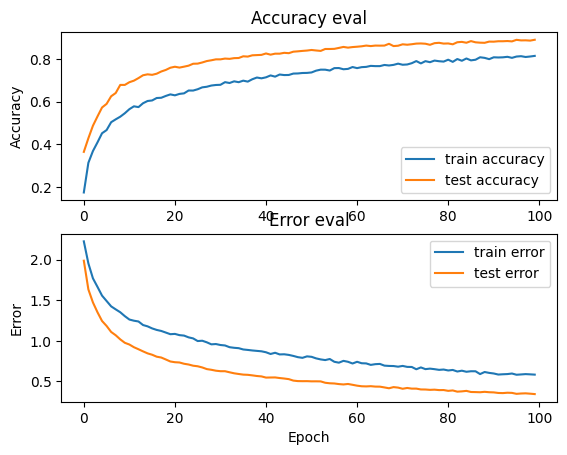

In [25]:
def plot_history(history):

    fig, axs = plt.subplots(2)

    # create accuracy sublpot
    axs[0].plot(history.history["accuracy"], label="train accuracy")
    axs[0].plot(history.history["val_accuracy"], label="test accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")
    axs[0].set_title("Accuracy eval")

    # create error sublpot
    axs[1].plot(history.history["loss"], label="train error")
    axs[1].plot(history.history["val_loss"], label="test error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Error eval")

    plt.show()


# plot accuracy and error as a function of the epochs
plot_history(history)

In [26]:
import pandas as pd
metrics_df = pd.DataFrame(history.history)
metrics_df.tail(10)

,accuracy,loss,val_accuracy,val_loss
90,0.808809,0.598521,0.882216,0.366055
91,0.807951,0.585469,0.884218,0.358982
92,0.808666,0.588876,0.884218,0.357361
93,0.811097,0.591339,0.885219,0.361860
94,0.806235,0.598027,0.883550,0.360011
95,0.812384,0.583036,0.890891,0.348172
96,0.813957,0.586780,0.888222,0.352394
97,0.810239,0.590894,0.888555,0.354404
98,0.812527,0.587855,0.887221,0.350050
99,0.815387,0.584522,0.891225,0.345169


In [31]:
# evaluate model on Test Set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=100)
print('\nTest accuracy:', test_acc)


Test accuracy: 0.8912245631217957


In [30]:
model.save("MusicGenre_CNN.h5")

In [43]:
# Plotting the confusion matrix for analizing the true positives and negatives
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score
#import matplotlib.pyplot as plt
#import seaborn as sns
#import
pred_x = model.predict(X_test)
predicted_index = np.argmax(pred_x, axis = 1)
print("Expected Index: {}, Predicted Index: {}".format(y_test, predicted_index))


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Expected Index: [4 0 8 ... 9 3 2], Predicted Index: [4 0 4 ... 9 3 2]


Accuracy: 0.8912245578912246


array([[273,   3,   3,   4,   0,   1,   3,   0,   3,   4],
       [  1, 318,   2,   0,   0,   5,   0,   0,   0,   2],
       [  7,   1, 267,   3,   0,   6,   2,   5,   3,  10],
       [  2,   2,   2, 268,   6,   0,   4,   8,   9,  19],
       [  1,   1,   4,   4, 260,   0,   1,  17,  13,   1],
       [  1,  23,   8,   0,   0, 255,   0,   2,   0,   1],
       [  0,   0,   0,   6,   3,   0, 257,   0,   1,  16],
       [  0,   1,   6,   8,   5,   2,   0, 260,   5,   3],
       [  2,   1,   4,   5,   4,   1,   1,   4, 270,   4],
       [  2,   5,  11,  17,   1,   2,   2,   4,   3, 243]])

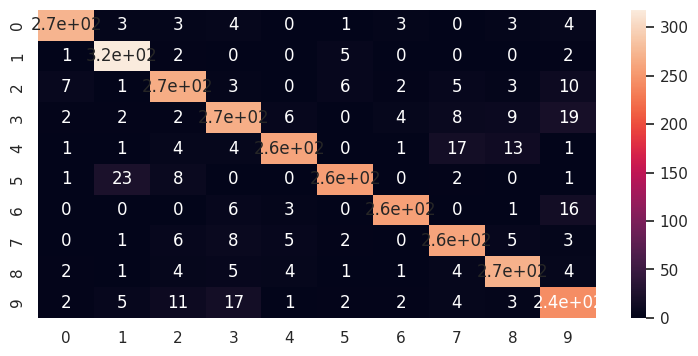

In [61]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# accuracy
accuracy=accuracy_score(y_test, predicted_index)
print('Accuracy:', accuracy)


cm = confusion_matrix(y_test,predicted_index)
sns.set(rc = {'figure.figsize':(9,4)})
sns.heatmap(cm, annot=True)
cm
#print(classification_report(y_test, predicted_index))

In [49]:
#!pip install scikit-plot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 34.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


In [56]:
#print(scipy.__version__)

1.13.1


In [55]:
#!pip install scipy==1.11.4

In [57]:
#import scikitplot as skplt

ImportError: cannot import name 'interp' from 'scipy' (/usr/local/lib/python3.11/dist-packages/scipy/__init__.py)

In [ ]:
#skplt.metrics.plot_confusion_matrix(y_test,predicted_index, normalilze=True)

## Conclusion
As expected CNN outperformed KNN and SVM. It produced best results in both testing and taring data. As we increased the number of epochs the loss percentage decreased with a gradual increase in accuracy scores. It can be clearly seen in the above validation plot in which the curves almost coincided with each other.

## References

1.[https://www.tensorflow.org/datasets/catalog/gtzan](https://www.tensorflow.org/datasets/catalog/gtzan)

2.[https://www.kaggle.com/code/dapy15/music-genre-classification](https://www.kaggle.com/code/dapy15/music-genre-classification)

3.[https://www.clairvoyant.ai/blog/music-genre-classification-using-cnn](https://www.clairvoyant.ai/blog/music-genre-classification-using-cnn)

4.[https://github.com/alikaratana/Music-Genre-Classification](https://github.com/alikaratana/Music-Genre-Classification)